# Assignment 3 - Probability


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random


### 1. Write a Python program to simulate the following scenarios:
  a. Tossing a coin 10,000 times and calculating the experimental probability of heads and tails.
  b. Rolling two dice and computing the probability of getting a sum of 7.

In [8]:
heads_count = 0
tails_count = 0
total_tosses = 10000

for i in range(total_tosses):
    toss = random.choice(["Heads", "Tails"])
    if toss == "Heads":
        heads_count += 1
    else:
        tails_count += 1

prob_heads = heads_count / total_tosses
prob_tails = tails_count / total_tosses

print("Probability of Heads:", prob_heads)
print("Probability of Tails:", prob_tails)

successful_rolls = 0
total_rolls = 10000

for i in range(total_rolls):
    die1 = random.randint(1, 6)
    die2 = random.randint(1, 6)
    if die1 + die2 == 7:
        successful_rolls += 1

prob_sum_7 = successful_rolls / total_rolls
print("Probability of sum 7:", prob_sum_7)

Probability of Heads: 0.4941
Probability of Tails: 0.5059
Probability of sum 7: 0.1713


**Explanation:** We simulate coin tosses using a loop that runs 10,000 times. We randomly pick "Heads" or "Tails" in each step and keep track of the counts. Finally, we divide the counts by 10,000 to find the probability. For the dice, we use another loop to simulate rolling two dice 10,000 times. In each roll, we generate a random number between 1 and 6 for both dice. If they add up to 7, we count it as a success, and then we calculate the probability.

### 2. Write a function to estimate the probability of getting at least one "6" in 10 rolls of a fair die.

In [9]:
def prob_at_least_one_six():
    successes = 0
    simulations = 10000
    
    for i in range(simulations):
        has_six = False
        for j in range(10):
            roll = random.randint(1, 6)
            if roll == 6:
                has_six = True
        
        if has_six:
            successes += 1
            
    return successes / simulations

result = prob_at_least_one_six()
print("Probability of at least one 6:", result)

Probability of at least one 6: 0.8402


**Explanation:** We create a function that runs 10,000 simulations. In each simulation, we roll a die 10 times. If a 6 appears in those 10 rolls, we mark it as successful. The final probability is the number of successful simulations divided by the total simulations.

### 3. A bag contains 5 red, 7 green, and 8 blue balls. A ball is drawn randomly, its color noted, and it is put back into the bag. If this process is repeated 1000 times, write a Python program to estimate:
  a. The probability of drawing a red ball given that the previous ball was blue.
  b. Verify Bayes' theorem with the simulation results.

In [10]:
bag = ["Red"] * 5 + ["Green"] * 7 + ["Blue"] * 8
total_draws = 10000

blue_count = 0
red_after_blue_count = 0
previous_ball = ""

for i in range(total_draws):
    current_ball = random.choice(bag)
    
    if previous_ball == "Blue":
        blue_count += 1
        if current_ball == "Red":
            red_after_blue_count += 1
            
    previous_ball = current_ball

if blue_count > 0:
    prob_red_given_blue = red_after_blue_count / blue_count
else:
    prob_red_given_blue = 0

print("Probability of Red given previous was Blue:", prob_red_given_blue)

prob_red = 5 / 20
prob_blue = 8 / 20
prob_blue_given_red = 8 / 20

bayes_result = (prob_blue_given_red * prob_red) / prob_blue
print("Bayes theorem result:", bayes_result)

Probability of Red given previous was Blue: 0.2441802872709262
Bayes theorem result: 0.25


**Explanation:** We simulate picking balls out of a bag 10,000 times. We check if the previous ball was blue. If it was, we check if the new ball is red and update our counts. To verify Bayes' Theorem, we calculate it mathematically since drawing with replacement means the probabilities are independent.

### 4. Generate a sample of size 1000 from a discrete random variable with the following distribution:
  - P(X=1) = 0.25
  - P(X=2) = 0.35
  - P(X=3) = 0.4
  Compute the empirical mean, variance, and standard deviation of the sample.

In [11]:
values = [1, 2, 3]
probabilities = [0.25, 0.35, 0.40]

sample = np.random.choice(values, size=1000, p=probabilities)

mean_val = np.mean(sample)
var_val = np.var(sample)
std_val = np.std(sample)

print("Mean:", mean_val)
print("Variance:", var_val)
print("Standard Deviation:", std_val)

Mean: 2.155
Variance: 0.6069749999999999
Standard Deviation: 0.7790860029547444


**Explanation:** We use NumPy to generate 1000 random samples based on the exact probability distribution given. Then, we use built-in NumPy functions to quickly calculate the mean, variance, and standard deviation.

### 5. Simulate 2000 random samples from an exponential distribution with a mean of 5. Visualize the distribution using:
  a. A histogram.
  b. A probability density function (PDF) overlay.

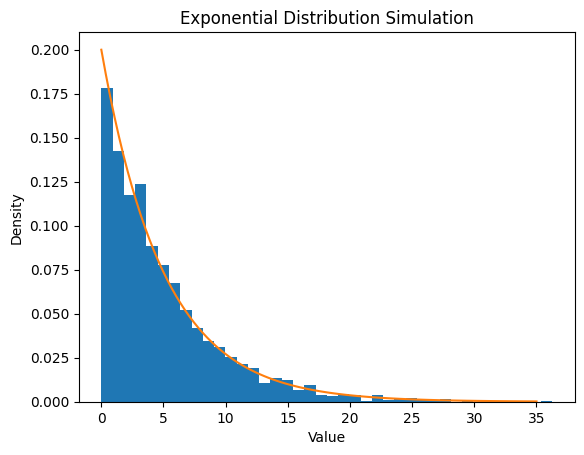

In [12]:
samples = np.random.exponential(scale=5, size=2000)

plt.figure()
plt.hist(samples, bins=40, density=True)

x = np.linspace(0, 35, 100)
pdf = (1/5) * np.exp(-x/5)
plt.plot(x, pdf)

plt.title("Exponential Distribution Simulation")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

**Explanation:** We generate 2000 random numbers from an exponential distribution with a scale (mean) of 5. Then we plot a histogram of this data, and overlay the actual probability density function curve over it using Matplotlib.

### 6. Simulate the Central Limit Theorem by following these steps
  a. Generate 10,000 random numbers from a uniform distribution.
  b. Draw 1000 samples of size n = 30.
  c. Calculate and visualize the distribution of sample means.

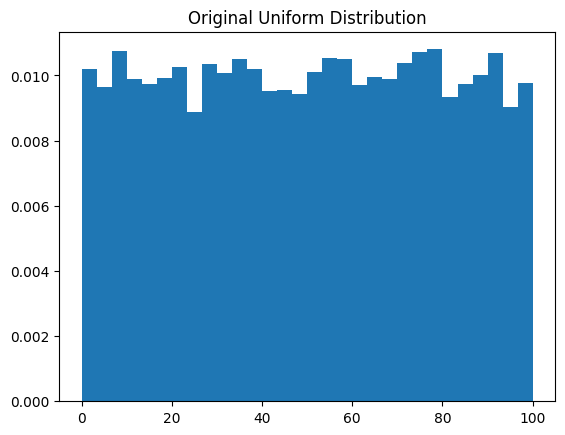

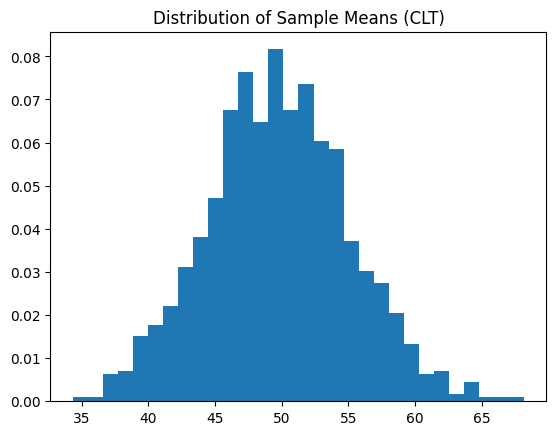

In [13]:
import numpy as np
import matplotlib.pyplot as plt

uniform_data = np.random.uniform(0, 100, 10000)

sample_means = []
for i in range(1000):
    sample = np.random.choice(uniform_data, size=30)
    sample_means.append(np.mean(sample))

plt.figure()
plt.hist(uniform_data, bins=30, density=True)
plt.title("Original Uniform Distribution")
plt.show()

plt.figure()
plt.hist(sample_means, bins=30, density=True)
plt.title("Distribution of Sample Means (CLT)")
plt.show()

**Explanation:** To demonstrate the Central Limit Theorem, we first create 10,000 random numbers using a uniform distribution. We then pick 1000 different samples of 30 items each and calculate their means. Finally, we plot both the original uniform data and the normal-looking sample means.